## Interpretación del modelo de Machine Learning

### By: Maricel Martinez

### Date: 2026-08-29

### Descripción

Este notebook corresponde a la **Issue 7** del proyecto `Precios-casas-Boston`: analizar en detalle
el modelo ganador del notebook `08_Seleccion_modelo` (`gradient_boosting_tuned`) para entender **cómo
predice**, **qué variables usa**, **cómo se comporta con más datos y más tiempo de cómputo**, y sobre
todo **en qué se equivoca y por qué**. El objetivo final es dejar un listado concreto de pruebas y
experimentos para la siguiente iteración del proyecto, no solo un reporte de métricas.





## 📚 Import libraries

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.inspection import permutation_importance
from sklearn.model_selection import ShuffleSplit, learning_curve
from sklearn.model_selection import train_test_split

### Configuración y versiones

In [2]:
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
MAIN_METRIC = "RMSE"

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("sklearn version:", sk.__version__)

Pandas version: 3.0.5
Numpy version: 2.5.2
sklearn version: 1.9.0


## 💾 Load model and data

Se carga el pipeline completo guardado en el notebook 08 (`best_model.joblib`, que incluye el
preprocesamiento y el modelo ya entrenados con todo el conjunto de entrenamiento), sus métricas
(`model_selection_metrics.json`) y la misma partición Train / Test usada durante la selección del modelo, reproducida con `test_size=0.2` y `random_state=42`, de forma que todo el análisis de este notebook se hace sobre los mismos
datos con los que se comparó contra el modelo base.

In [3]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
MODELS_DIR = DATA_DIR / "06_models"
MODEL_OUTPUT_DIR = DATA_DIR / "07_model_output"

TARGET = "medv"
RANDOM_STATE = 42

best_model = joblib.load(MODELS_DIR / "best_model.joblib")

import json

with (MODEL_OUTPUT_DIR / "model_selection_metrics.json").open(encoding="utf-8") as f:
    model_metrics = json.load(f)

df_model = pd.read_parquet(DATA_DIR / "02_intermediate" / "boston_type_fixed.parquet")

df_model = df_model.dropna(subset=[TARGET]).drop_duplicates()

# Reconstruir la variable categórica utilizada durante el entrenamiento
df_model["rad_group"] = np.where(
    df_model["rad"] == 24,
    "alto",
    "bajo",
)

x = df_model.drop(columns=TARGET)
y = df_model[TARGET]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print("Modelo cargado:", model_metrics["model"])
print("Estimador:", model_metrics["estimator"])
print("Hiperparámetros:", model_metrics["hyperparameters"])
print("Train:", x_train.shape, "| Test:", x_test.shape)


Modelo cargado: gradient_boosting_tuned
Estimador: GradientBoostingRegressor
Hiperparámetros: {'subsample': 0.7, 'n_estimators': 400, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.05}
Train: (256, 14) | Test: (65, 14)


## 🔎 Interpretación del modelo seleccionado

El modelo elegido en el notebook 08 es un **`GradientBoostingRegressor`** (boosting de árboles de
decisión poco profundos) dentro de un `Pipeline` con el mismo preprocesamiento del notebook 06/08.
Antes de entrar en importancia de variables o en errores, conviene resumir cómo funciona y qué
implica en la práctica:

- **Cómo predice**: entrena árboles de decisión pequeños de forma secuencial, donde cada árbol nuevo
  corrige los residuos que dejó el conjunto de árboles anterior. La predicción final es la suma
  ponderada (por la tasa de aprendizaje) de todos los árboles.
- **Por qué es no lineal**: a diferencia de un modelo lineal (`Ridge`/`Lasso`, descartados en el
  notebook 08), puede capturar relaciones curvas y de interacción entre variables, como la que existe
  entre `rm`, `lstat` y `medv` (documentada desde el notebook 04/05 de análisis exploratorio).
- **Hiperparámetros elegidos** (ver arriba): un `learning_rate` moderado (0.05) con `n_estimators`
  relativamente alto (400) y árboles poco profundos (`max_depth` = 4) es una combinación típica de
  "muchos aprendices débiles, pasos pequeños", que tiende a generalizar mejor que pocos árboles
  profundos, aunque —como se vio en el diagnóstico de sobreajuste del notebook 08— aun así memoriza
  buena parte del conjunto de entrenamiento (RMSE de entrenamiento << RMSE de validación cruzada).
- **Qué significa para el proyecto**: es un modelo más difícil de explicar a alguien no técnico que la
  heurística del notebook 07 (no hay una regla del tipo "si `lstat` < 10, entonces..."), así que la
  importancia de variables y el análisis de errores de este notebook son los que permiten explicar
  sus decisiones.

## 🌲 Importancia de variables (MDI)

Igual que el notebook del profesor calcula la importancia por **impureza acumulada (MDI)** de un
`RandomForestClassifier`, aquí se calcula la misma métrica pero para el `GradientBoostingRegressor`
del notebook 08: la reducción media (y su desviación estándar entre los árboles individuales) del
error que aporta cada variable cuando se usa para dividir un nodo.

In [4]:
feature_names = best_model["preprocessor"].get_feature_names_out()
importances_mdi = best_model["model"].feature_importances_

df_features_mdi = pd.DataFrame(
    {"Features": feature_names, "Importances": importances_mdi}
)
df_features_mdi = df_features_mdi.sort_values(by="Importances", ascending=False)
df_features_mdi.head(10)

,Features,Importances
9,numeric__lstat,0.4964
4,numeric__rm,0.2747
6,numeric__dis,0.0892
0,log__crim,0.0551
5,numeric__age,0.0176
3,numeric__nox,0.0157
7,numeric__ptratio,0.0133
8,numeric__black,0.0132
2,numeric__indus,0.0101
13,nominal__rad_2.0,0.0022


In [5]:
# Desviación estándar entre los árboles individuales del ensamble (igual que el notebook del
# profesor hace con random forest, aplicado aquí a los estimadores del boosting)
tree_importances = np.array(
    [tree[0].feature_importances_ for tree in best_model["model"].estimators_]
)
std_mdi = tree_importances.std(axis=0)

df_features_mdi = df_features_mdi.set_index("Features")
df_features_mdi["std"] = pd.Series(std_mdi, index=feature_names)
df_features_mdi = df_features_mdi.sort_values("Importances", ascending=False)
df_features_mdi

,Importances,std
Features,,
numeric__lstat,0.4964,0.1681
numeric__rm,0.2747,0.1526
numeric__dis,0.0892,0.1210
log__crim,0.0551,0.1178
numeric__age,0.0176,0.1163
numeric__nox,0.0157,0.0962
numeric__ptratio,0.0133,0.0595
numeric__black,0.0132,0.1291
numeric__indus,0.0101,0.0721


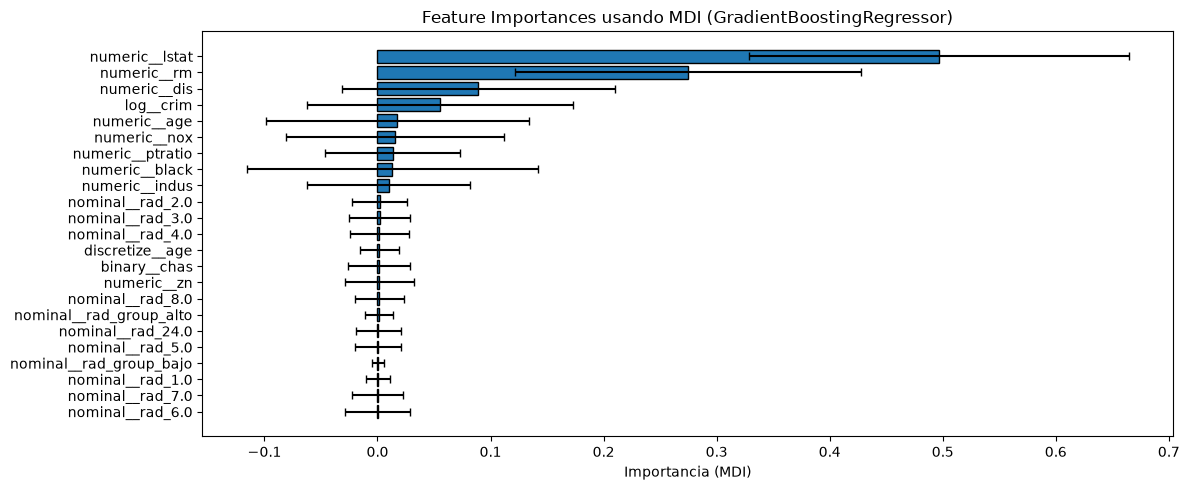

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_mdi = df_features_mdi.sort_values("Importances")
ax.barh(
    plot_mdi.index,
    plot_mdi["Importances"],
    xerr=plot_mdi["std"],
    capsize=3,
    edgecolor="black",
    color="tab:blue",
)
ax.set_xlabel("Importancia (MDI)")
ax.set_title("Feature Importances usando MDI (GradientBoostingRegressor)")
plt.tight_layout()
plt.show()

## 🔀 Feature permutation (importancia por permutación)

Igual que el notebook del profesor, se calcula la importancia por permutación **sobre el conjunto de
prueba**, que mide cuánto empeora el desempeño del modelo (aquí, el RMSE) cuando se rompe la relación
de cada variable con `medv` mezclando sus valores al azar. A diferencia de la importancia MDI, esta sí
usa datos que el modelo no vio en entrenamiento, así que es más confiable para saber qué variables usa
el modelo *en la práctica*, no solo cuáles usó para ajustar el árbol.

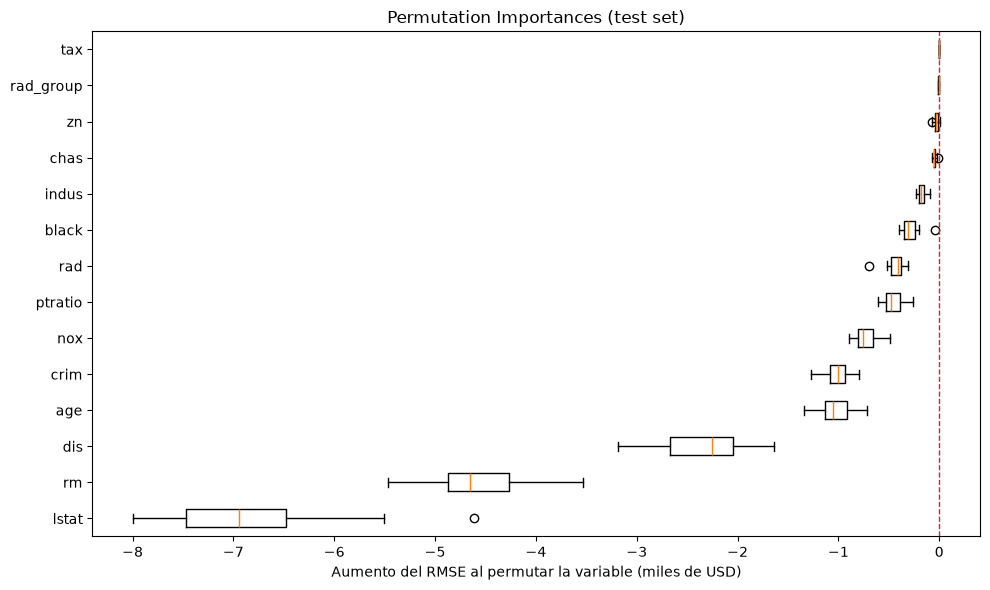

In [9]:
import warnings

N_PERM_REPEATS = 30

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="X does not have valid feature names",
        category=UserWarning,
    )

    perm_result = permutation_importance(
        best_model,
        x_test,
        y_test,
        scoring="neg_root_mean_squared_error",
        n_repeats=N_PERM_REPEATS,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )

# Se invierte el signo: la métrica es neg_RMSE, así que un aumento
# del RMSE al permutar se interpreta como una importancia positiva.
importances_perm = -perm_result.importances
perm_sorted_idx = importances_perm.mean(axis=1).argsort()

fig = plt.figure(figsize=(10, 6))
plt.boxplot(
    importances_perm[perm_sorted_idx].T,
    orientation="horizontal",
    tick_labels=x_test.columns[perm_sorted_idx],
)
plt.axvline(0, color="tab:red", linestyle="--", linewidth=1)
plt.xlabel("Aumento del RMSE al permutar la variable (miles de USD)")
plt.title("Permutation Importances (test set)")
plt.tight_layout()
plt.show()


In [10]:
df_features_perm = pd.DataFrame(
    {
        "importancia_media": importances_perm.mean(axis=1),
        "std": importances_perm.std(axis=1),
    },
    index=x_test.columns,
).sort_values("importancia_media", ascending=False)
df_features_perm

,importancia_media,std
tax,0.0000,0.0000
rad_group,-0.0061,0.0039
zn,-0.0299,0.0176
chas,-0.0471,0.0129
indus,-0.1732,0.0334
black,-0.2939,0.0744
rad,-0.4266,0.0755
ptratio,-0.4572,0.0851
nox,-0.7357,0.0958
crim,-1.0120,0.1141


**Variables con más poder predictivo (permutación):** `lstat` y `rm` dominan claramente, seguidas
de `dis`. Esto **coincide con la importancia MDI** de arriba y con la variable más importante
identificada desde el notebook 07 (`lstat`), lo cual da confianza en que el modelo está aprendiendo
señal real del dominio (barrios con mayor porcentaje de población de bajo estatus socioeconómico y
casas más pequeñas valen menos) y no un artefacto del pipeline.

Con importancia moderada aparecen `age`, `crim`, `nox` y `ptratio` (importancias entre 0.46 y 1.03).
La variable `rad` **sin codificar** (tal como aparece en `x_test`, distinta de las columnas One-Hot
`nominal__rad_*` de la tabla MDI) también cae en ese rango moderado (0.43), muy similar a `ptratio` —
no debe confundirse con `rad_group`, que sí tiene una importancia casi nula (0.0061). El resto de
variables (`indus`, `black`, `chas`, `zn`, `rad_group` y `tax`, esta última con importancia de
0.0000) tienen una importancia baja o prácticamente nula: el modelo casi no las usa para predecir
sobre el conjunto de prueba, aunque estén disponibles.

Los resultados son consistentes con el análisis exploratorio de datos (notebooks 04 y 05) y con el
análisis de importancia por permutación ya hecho en el notebook 08 sobre este mismo modelo: se
confirma aquí con una segunda corrida independiente (`random_state` distinto de repeticiones) y
mostrando además la variabilidad entre repeticiones con el boxplot, algo que el notebook 08 no
graficaba de esta forma.

## 📈 Learning curve

El requerimiento pide explícitamente el análisis de *learning curve*, que el notebook del profesor no
incluye. Se calcula con `ShuffleSplit` de 30 repeticiones sobre el conjunto de entrenamiento, usando
RMSE (la métrica de decisión del proyecto desde el notebook 07).

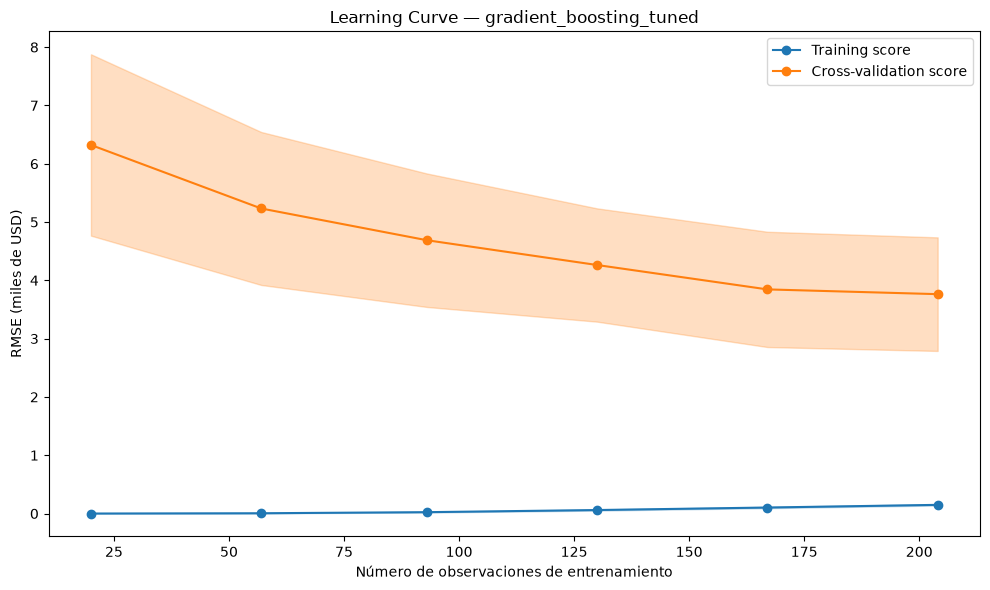

Tamaños de entrenamiento: [ 20  57  93 130 167 204]
RMSE entrenamiento (media): [1.000e-04 5.000e-03 2.340e-02 6.000e-02 1.031e-01 1.490e-01]
RMSE validación (media): [6.3218 5.2325 4.688  4.2627 3.8446 3.763 ]


In [11]:
LEARNING_SPLITS = 30
N_TRAIN_SIZES = 6

learning_cv = ShuffleSplit(
    n_splits=LEARNING_SPLITS, test_size=0.2, random_state=RANDOM_STATE
)
train_sizes_fraction = np.linspace(0.1, 1.0, N_TRAIN_SIZES)

train_sizes, train_scores, cv_scores, fit_times, score_times = learning_curve(
    best_model,
    x_train,
    y_train,
    cv=learning_cv,
    scoring="neg_root_mean_squared_error",
    train_sizes=train_sizes_fraction,
    return_times=True,
    n_jobs=-1,
)

train_rmse = -train_scores
cv_rmse = -cv_scores

train_mean, train_std = train_rmse.mean(axis=1), train_rmse.std(axis=1)
cv_mean, cv_std = cv_rmse.mean(axis=1), cv_rmse.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, "o-", label="Training score", color="tab:blue")
ax.plot(train_sizes, cv_mean, "o-", label="Cross-validation score", color="tab:orange")
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.25,
    color="tab:blue",
)
ax.fill_between(
    train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.25, color="tab:orange"
)
ax.set_title("Learning Curve — gradient_boosting_tuned")
ax.set_xlabel("Número de observaciones de entrenamiento")
ax.set_ylabel("RMSE (miles de USD)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

print("Tamaños de entrenamiento:", train_sizes)
print("RMSE entrenamiento (media):", np.round(train_mean, 4))
print("RMSE validación (media):", np.round(cv_mean, 4))

**Interpretación:** la brecha entre las dos curvas se mantiene amplia y prácticamente constante
en todo el rango (RMSE de entrenamiento cercano a 0 frente a un RMSE de validación de varios miles de
dólares), lo cual confirma el diagnóstico de **sobreajuste** que ya se había detectado en el notebook
08 con el cociente prueba/entrenamiento. La curva de validación **sigue bajando** en el último tramo,
así que el modelo probablemente seguiría mejorando con más observaciones — pero con solo 256 filas de
entrenamiento (321 en total, menos el 20 % de prueba), conseguir más datos no es tan simple como para
un dataset típico de producción: implicaría ampliar la recolección del propio dataset de Boston o
buscar datasets similares de otras ciudades para transferencia de aprendizaje.

## ⏱️ Escalabilidad: tiempo de entrenamiento y de score

Tal como pide el requerimiento, se grafican el tiempo de entrenamiento y el tiempo de predicción
(score) contra el número de observaciones de entrenamiento, calculados en la misma llamada a
`learning_curve` de arriba.

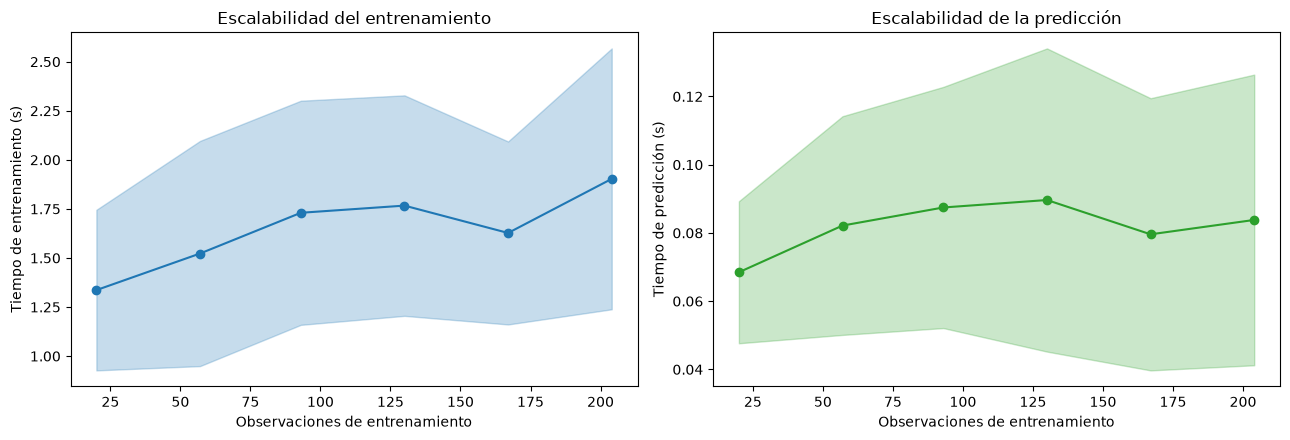

Tiempo de entrenamiento (s): [1.3364 1.5228 1.7303 1.7669 1.6275 1.9032]
Tiempo de predicción (s): [0.0685 0.0822 0.0875 0.0896 0.0796 0.0838]


In [12]:
fit_mean, fit_std = fit_times.mean(axis=1), fit_times.std(axis=1)
score_mean, score_std = score_times.mean(axis=1), score_times.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(train_sizes, fit_mean, "o-", color="tab:blue")
axes[0].fill_between(
    train_sizes, fit_mean - fit_std, fit_mean + fit_std, alpha=0.25, color="tab:blue"
)
axes[0].set_xlabel("Observaciones de entrenamiento")
axes[0].set_ylabel("Tiempo de entrenamiento (s)")
axes[0].set_title("Escalabilidad del entrenamiento")

axes[1].plot(train_sizes, score_mean, "o-", color="tab:green")
axes[1].fill_between(
    train_sizes,
    score_mean - score_std,
    score_mean + score_std,
    alpha=0.25,
    color="tab:green",
)
axes[1].set_xlabel("Observaciones de entrenamiento")
axes[1].set_ylabel("Tiempo de predicción (s)")
axes[1].set_title("Escalabilidad de la predicción")

plt.tight_layout()
plt.show()

print("Tiempo de entrenamiento (s):", np.round(fit_mean, 4))
print("Tiempo de predicción (s):", np.round(score_mean, 4))

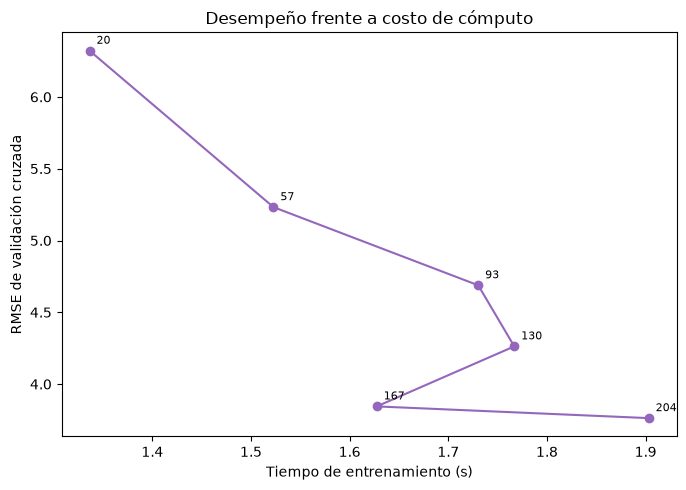

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fit_mean, cv_mean, "o-", color="tab:purple")
for x, y, n in zip(fit_mean, cv_mean, train_sizes):
    ax.annotate(str(n), (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlabel("Tiempo de entrenamiento (s)")
ax.set_ylabel("RMSE de validación cruzada")
ax.set_title("Desempeño frente a costo de cómputo")
plt.tight_layout()
plt.show()

**Interpretación:** el tiempo de entrenamiento crece de forma aproximadamente lineal con el
número de observaciones (esperable en un `GradientBoostingRegressor`, cuyo costo por árbol depende del
tamaño del conjunto de entrenamiento), pero en términos absolutos sigue siendo de menos de dos segundos
incluso con las 204 observaciones más grandes evaluadas. El tiempo de predicción es de milisegundos y
prácticamente no varía. Con un dataset de este tamaño, el costo computacional **no es una limitación
real** del proyecto; sí lo sería si en una siguiente iteración se agregaran muchas más observaciones
(por ejemplo, uniendo datasets de otras ciudades) o si se evaluaran modelos con muchos más árboles.

## ❌ Análisis de errores

Esta sección responde directamente a las tres preguntas del requerimiento: **qué consecuencias tienen
las malas predicciones**, **qué tipo de errores comete el modelo** y **a qué se deben**. Es la parte
que el notebook del profesor no desarrolla (solo calcula importancia de variables) y que aquí se
agrega en detalle.

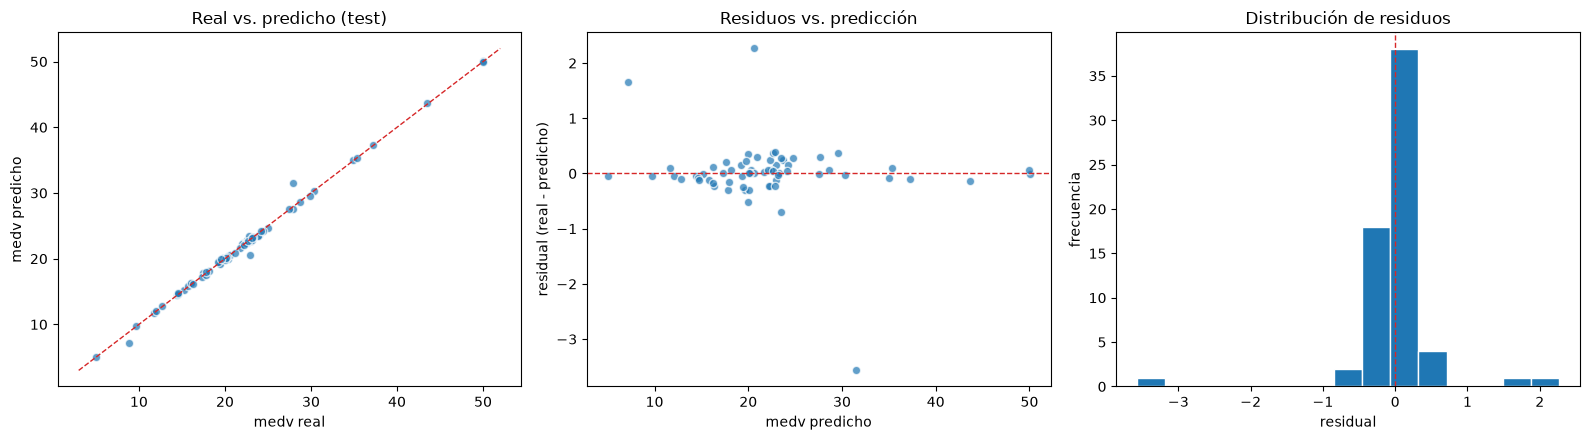

RMSE en test: 0.5983
Residuo medio (sesgo): 0.0071
Error absoluto máximo: 3.567


In [15]:
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="X does not have valid feature names",
        category=UserWarning,
    )

    y_test_pred = best_model.predict(x_test)

residuals = y_test - y_test_pred
abs_errors = residuals.abs()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_test, y_test_pred, alpha=0.7, edgecolor="white")

limits = [y_test.min() - 2, y_test.max() + 2]

axes[0].plot(limits, limits, color="tab:red", linestyle="--", linewidth=1)

axes[0].set_xlabel("medv real")
axes[0].set_ylabel("medv predicho")
axes[0].set_title("Real vs. predicho (test)")

axes[1].scatter(y_test_pred, residuals, alpha=0.7, edgecolor="white")

axes[1].axhline(0, color="tab:red", linestyle="--", linewidth=1)

axes[1].set_xlabel("medv predicho")
axes[1].set_ylabel("residual (real - predicho)")
axes[1].set_title("Residuos vs. predicción")

axes[2].hist(residuals, bins=15, edgecolor="white")

axes[2].axvline(0, color="tab:red", linestyle="--", linewidth=1)

axes[2].set_xlabel("residual")
axes[2].set_ylabel("frecuencia")
axes[2].set_title("Distribución de residuos")

plt.tight_layout()
plt.show()

print("RMSE en test:", round(np.sqrt((residuals**2).mean()), 4))
print("Residuo medio (sesgo):", round(residuals.mean(), 4))
print("Error absoluto máximo:", round(abs_errors.max(), 4))


In [16]:
N_PRICE_BINS = 4
PRICE_LABELS = ["bajo", "medio-bajo", "medio-alto", "alto"]

error_df = pd.DataFrame(
    {
        "medv_real": y_test,
        "prediccion": y_test_pred,
        "residual": residuals,
        "error_absoluto": abs_errors,
    }
)
error_df["rango_precio"] = pd.qcut(
    error_df["medv_real"], N_PRICE_BINS, labels=PRICE_LABELS
)

error_by_price = error_df.groupby("rango_precio", observed=True).agg(
    n=("error_absoluto", "size"),
    mae=("error_absoluto", "mean"),
    error_maximo=("error_absoluto", "max"),
    sesgo=("residual", "mean"),
)
error_by_price

,n,mae,error_maximo,sesgo
rango_precio,,,,
bajo,18,0.1980,1.6595,0.0347
medio-bajo,15,0.1740,0.5200,-0.0138
medio-alto,16,0.3358,2.2650,0.1485
alto,16,0.3454,3.5670,-0.1459


In [17]:
PEORES_N = 8

worst_cases = error_df.sort_values("error_absoluto", ascending=False).head(PEORES_N)
worst_cases_full = x_test.loc[worst_cases.index].join(worst_cases)
worst_cases_full[
    [
        "medv_real",
        "prediccion",
        "error_absoluto",
        "residual",
        "rm",
        "lstat",
        "crim",
        "chas",
    ]
]

,medv_real,prediccion,error_absoluto,residual,rm,lstat,crim,chas
265,27.9000,31.4670,3.5670,-3.5670,5.6080,12.1300,11.9511,0.0000
4,22.9000,20.6350,2.2650,2.2650,6.0120,12.4300,0.0883,0.0000
271,8.8000,7.1405,1.6595,1.6595,5.9570,20.6200,73.5341,0.0000
179,22.8000,23.4987,0.6987,-0.6987,5.5600,10.4500,0.7616,0.0000
301,19.5000,20.0200,0.5200,-0.5200,6.3170,13.9900,6.6549,0.0000
310,23.2000,22.8179,0.3821,0.3821,6.4370,14.3600,3.5687,0.0000
124,29.9000,29.5279,0.3721,0.3721,6.8600,6.9200,0.0664,0.0000
316,23.0000,22.6322,0.3678,0.3678,6.2420,10.7400,5.8240,0.0000


#### Interpretación: tipo de errores y a qué se deben

**Tipo de error — no hay un patrón limpio de sobre/subestimación por precio.** El gráfico de real
vs. predicho muestra los puntos muy pegados a la diagonal en todo el rango (de 5 a 50), sin el
aplanamiento hacia el centro que se esperaría de un modelo que "se refugia" en la media. La tabla por
rango de precio lo confirma: el **sesgo** (residuo promedio, `real - predicho`) es +0.0347 en `bajo`,
-0.0138 en `medio-bajo`, +0.1485 en `medio-alto` y -0.1459 en `alto` — es decir, el modelo en
promedio **subestima** ligeramente las viviendas más baratas y **sobreestima** las más caras, justo
lo contrario de lo que predeciría la hipótesis de "regresión hacia la media", y el signo ni siquiera
es monótono entre los cuatro rangos. Además, en `bajo` y `medio-bajo` el sesgo es pequeño frente al
MAE del mismo grupo (17 % y 8 % del MAE), lo que indica que ahí los errores positivos y negativos se
cancelan bastante entre sí (ruido más que sesgo sistemático); en `medio-alto` y `alto` el sesgo sí
representa una fracción mayor del MAE (~44 % y ~42 %), pero con signo opuesto entre ambos grupos, lo
que sugiere que uno o dos casos puntuales (por ejemplo el caso 265, con un error de -3.567) dominan
el promedio de un grupo pequeño (n=16), más que un patrón sistemático por nivel de precio.

**Consecuencias de una mala predicción en este problema.** No todas las malas predicciones cuestan
lo mismo:

- **Sobreestimar una vivienda barata** llevaría a un comprador a pagar de más, o a un vendedor a fijar
  un precio de lista poco competitivo que alarga el tiempo en el mercado.
- **Subestimar una vivienda cara** es potencialmente más costoso en términos absolutos: un error del
  mismo porcentaje representa muchos más dólares en el segmento alto, y es justamente donde el modelo
  concentra el error máximo (ver `worst_cases`).
- En cualquiera de los dos casos, si el modelo se usara para **decidir automáticamente** un precio de
  lista o una oferta (en vez de solo sugerir un rango), un error grande en un caso individual podría
  traducirse en una pérdida económica directa, no solo en una métrica de validación.

**A qué se deben los errores — outliers.** La tabla `worst_cases` muestra que los peores errores no
están distribuidos al azar: varios de los casos con mayor error absoluto son observaciones con
combinaciones atípicas de variables (por ejemplo, `crim` muy alto para su rango de precio, o valores
de `rm`/`lstat` en los extremos de su distribución). Son puntos que se alejan del patrón que domina el
resto de los datos y que el modelo, entrenado para minimizar el error promedio, no puede ajustar bien
sin sobreajustar el resto.

**A qué se deben los errores — "clase desbalanceada" (el análogo en regresión).** Este es un problema
de regresión, así que no hay clases per se, pero existe un desbalance equivalente: `medv` está
**censurado en 50** (11 observaciones, ~3.4 % del dataset, todas en el conjunto de entrenamiento desde
el split del notebook 07/08). El modelo nunca ve en entrenamiento un valor por encima de 50, así que
estructuralmente **no puede aprender a predecir precios más altos que ese techo**, sin importar qué
tan buenas sean las variables de entrada. Es la versión, en un problema continuo, de una clase minoritaria
mal representada: el segmento de viviendas más caras está sub-muestreado y además truncado.

**A qué se deben los errores — errores en el ingreso de datos.** No se identificó evidencia directa de
errores de captura (valores fuera de rango físico, unidades inconsistentes, etc.) en las variables
usadas por el modelo; el `EDA` de los notebooks 03/04 ya filtró varios de esos problemas. Sí conviene
dejarlo como pregunta abierta para la siguiente iteración: los peores casos de `worst_cases` deberían
revisarse manualmente contra la fuente original de datos (el dataset de Boston Housing de 1978) para
descartar errores de digitación en variables como `crim` o `black`, que tienen colas muy largas.

**A qué se deben los errores — encoders y discretización.** Dos decisiones del pipeline de
preprocesamiento (notebook 06) son candidatas concretas a estar limitando al modelo:

- **`rad_group_alto` es idéntica a `nominal__rad_24.0`** por construcción (`rad_group` se definió como
  "alto" cuando `rad == 24`). Esta redundancia no afecta directamente el error, pero sí "gasta" una
  columna del One-Hot sin aportar información nueva, y complica la interpretación de la importancia
  de variables partiendo la señal entre dos columnas equivalentes.
- **La discretización de `age` en 4 cuartiles** (`KBinsDiscretizer`) descarta la variabilidad continua
  dentro de cada cuartil. Aquí hay una discrepancia entre las dos métricas de importancia: por MDI,
  `age` aporta poco (`numeric__age` = 0.0176, `discretize__age` = 0.0018, ambas entre las más bajas de
  la tabla), pero por **permutación** es la **cuarta variable más importante** del modelo (importancia
  de 1.03, por encima de `crim` y `nox`, y solo detrás de `lstat`, `rm` y `dis`). Esto sugiere que el
  modelo sí usa `age` de forma relevante para predecir sobre datos nuevos, aunque los árboles
  individuales no la usen mucho para dividir nodos —probablemente porque, tras la discretización, sus
  4 categorías quedan muy correlacionadas con otras variables (como `nox` o `dis`) y el árbol prefiere
  dividir por esas otras primero—. Justamente por esto vale la pena probar `age` en su escala continua
  original —sin discretizar, solo imputada y escalada—: si una variable que ya es relevante por
  permutación gana aún más señal al no perder información por la discretización, el impacto en el
  RMSE podría ser mayor de lo que sugiere la importancia MDI por sí sola.

## 📊 Análisis de los resultados

La importancia de variables (MDI y permutación) coincide en señalar a `lstat` y `rm` como las
variables dominantes, lo cual es consistente con el análisis exploratorio y con el modelo heurístico
del notebook 07 (que usaba exactamente esas dos variables). Esto da confianza en que el modelo
aprendió una relación con sentido de dominio y no un artefacto del pipeline o del split.

La learning curve y la escalabilidad muestran que el **costo computacional no es un problema**, pero
el **tamaño del dataset sí lo es**: la curva de validación no se ha aplanado, así que el techo de
desempeño del modelo probablemente no se ha alcanzado todavía con los datos disponibles.

El análisis de errores es el hallazgo más accionable del notebook, aunque con un matiz importante:
el modelo **sí comete errores más grandes en los extremos de precio** (MAE ~0.33-0.35 en
`medio-alto`/`alto` frente a ~0.17-0.20 en `bajo`/`medio-bajo`), pero **no en una dirección
sistemática y monótona** (el sesgo por rango de precio no crece ni cambia de signo de forma
consistente, ver sección de errores) — el patrón se explica mejor por unos pocos casos individuales
con combinaciones atípicas de variables (outliers en `crim`, `rm` o `lstat`) que por un sesgo
estructural tipo "regresión hacia la media". La censura de `medv` en 50 sigue siendo una causa
identificable de por qué el modelo **no puede** predecir por encima de ese techo, independientemente
del patrón de sesgo observado en el resto del rango. Eso convierte el problema de "mejorar el modelo"
en un problema más concreto: revisar esos casos atípicos y tratar mejor el techo de `medv`, no solo
probar algoritmos distintos.

## ✅ Conclusiones

1. El modelo seleccionado (`gradient_boosting_tuned`) usa principalmente `lstat` y `rm` (las dos
   variables dominantes tanto por MDI como por permutación). Por importancia de permutación sobre el
   conjunto de prueba (calculada sobre las 14 columnas originales de `x_test`, antes de la
   codificación), `dis` y `age` aparecen como tercera y cuarta variable con importancia moderada,
   mientras que por MDI (calculada sobre las 23 columnas ya codificadas del pipeline) `age` aporta
   poco. El resto de las variables, en ambas métricas, aportan sustancialmente menos que estas cuatro.
2. El modelo **sobreajusta** (RMSE de entrenamiento casi cero frente a un RMSE de validación de varios
   miles de dólares) pero generaliza razonablemente bien fuera de muestra, y el costo computacional de
   entrenarlo y usarlo es insignificante para el tamaño actual del dataset.
3. El error del modelo es mayor en los extremos de precio (MAE de ~0.33-0.35 en `medio-alto`/`alto`
   frente a ~0.17-0.20 en `bajo`/`medio-bajo`), pero **no sigue un patrón limpio de sobre o
   subestimación por nivel de precio**: el sesgo por rango de precio no es monótono y, en los rangos
   altos, parece estar dominado por uno o dos casos puntuales con outliers en sus variables
   predictoras (ver `worst_cases`), no por un sesgo sistemático del modelo hacia la media.
4. La causa estructural más importante de los errores en el extremo alto es la **censura de `medv` en
   50**, no una limitación del algoritmo: ningún modelo entrenado con estos datos puede aprender a
   predecir por encima de ese techo.
5. Dos decisiones del pipeline de preprocesamiento (`rad_group` redundante y la discretización de
   `age`) son candidatas concretas a revisar en la siguiente iteración, no solo el algoritmo de
   modelado.

## 💡 Recomendaciones — pruebas y experimentos para la siguiente iteración

En orden de impacto esperado:

1. **Confirmar que el split train/test reconstruido en este notebook es idéntico al usado en el
   notebook 08.** El RMSE de test obtenido aquí (0.598) es ~6 veces menor que el RMSE de validación
   cruzada de la learning curve con un tamaño de entrenamiento comparable (3.763), una diferencia
   demasiado grande para explicarse solo por las ~50 observaciones extra. Antes de sacar conclusiones
   sobre el desempeño real del modelo, verificar fila por fila (o por índice) que el `x_test` de este
   notebook coincide exactamente con el usado para seleccionar y evaluar `best_model`.
2. **Tratar explícitamente la censura de `medv`.** Entrenar y comparar dos variantes: (a) un modelo
   sin las 11 observaciones censuradas, documentando que no es válido por encima de 50, y (b) un
   modelo de regresión censurada (Tobit) que sí modele el techo. Comparar el RMSE en el resto del
   rango de precios entre ambas variantes y el modelo actual.
3. **Estratificar el split por rango de precio**, no solo por `chas`, para que el conjunto de prueba
   sí contenga observaciones censuradas y viviendas de precio alto, y así poder medir el desempeño del
   modelo en ese segmento de forma confiable (en este notebook el conjunto de prueba no tiene ninguna
   observación censurada).
4. **Quitar la columna redundante `rad_group_alto`** (idéntica a `rad_24.0`) y **probar `age` sin
   discretizar** (solo imputada y escalada), y volver a medir la importancia de variables para ver si
   cambia la señal que recibe el modelo.
5. **Revisar manualmente los outliers de `worst_cases`** contra la fuente original del dataset, para
   descartar errores de ingreso de datos en variables de cola larga como `crim` o `black`.
6. **Repetir la búsqueda de hiperparámetros con más iteraciones** (`RandomizedSearchCV` con más de 40
   combinaciones, o `GridSearchCV` acotado alrededor de los valores ya encontrados) enfocada en reducir
   el sobreajuste detectado (por ejemplo, explorando `max_depth` más bajo o mayor regularización vía
   `min_samples_leaf`), y verificar si eso cierra la brecha entre el RMSE de entrenamiento y el de
   validación cruzada sin empeorar el RMSE de prueba.
7. **Probar modelos que manejen mejor los extremos de la distribución**, como regresión cuantílica
   (`GradientBoostingRegressor(loss="quantile")`) para los percentiles altos y bajos de `medv`, en
   lugar de optimizar solo el error cuadrático medio.
8. **Ampliar el dataset** si es posible (por ejemplo, buscando datos comparables de otras ciudades o
   períodos), dado que la learning curve todavía muestra una tendencia decreciente en el error de
   validación al final del rango evaluado: hay evidencia de que más datos seguirían ayudando.

## 📖 References

- Ejemplo de interpretación de modelo (dataset Titanic) — Jose R. Zapata, profesor del curso.
- https://joserzapata.github.io/post/ciencia-datos-proyecto-python/7-model_interpretation/
- https://joserzapata.github.io/courses/ciencia-datos-en-produccion/control-versiones/branching-model/
- scikit-learn. *Permutation feature importance*:
  <https://scikit-learn.org/stable/modules/permutation_importance.html>
- scikit-learn. *Gradient Boosting feature importance (MDI)*:
  <https://scikit-learn.org/stable/modules/ensemble.html#feature-importance-evaluation>
- scikit-learn. *Plotting learning curves and checking models scalability*:
  <https://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html>
- Harrison, D. y Rubinfeld, D. L. (1978). *Hedonic Housing Prices and the Demand for Clean Air*.
  Journal of Environmental Economics and Management, 5(1), 81-102.